# RAG Pipeline Evaluation Analysis

This notebook analyzes the retrieval metrics generated by our experiment runner.

In [1]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Experiment Data

In [2]:
results_dir = Path("../results/metrics")
json_files = list(results_dir.glob("*.json"))

data = []
for file in json_files:
    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)
        agg = content["aggregate_metrics"]
        
        # Extract strategy name from filename (e.g. fixed_256_dense.json)
        strategy = file.stem.split('_')[-1].capitalize()
        
        data.append({
            "Strategy": strategy,
            "Hit Rate@1": agg["retrieval"]["hit_rate@1"],
            "Hit Rate@3": agg["retrieval"]["hit_rate@3"],
            "Hit Rate@5": agg["retrieval"]["hit_rate@5"],
            "MRR@5": agg["retrieval"]["mrr@5"],
            "Latency (ms)": agg["latency"]["retrieval_ms"]
        })

df = pd.DataFrame(data).sort_values(by="Hit Rate@5", ascending=False)
display(df)

,Strategy,Hit Rate@1,Hit Rate@3,Hit Rate@5,MRR@5,Latency (ms)
2,Hybrid,0.84,0.96,0.98,0.904000,28.898139
1,Dense,0.86,0.94,0.94,0.890000,18.227434
0,Bm25,0.62,0.82,0.84,0.711667,12.623053


## 2. Visualize Hit Rate and MRR

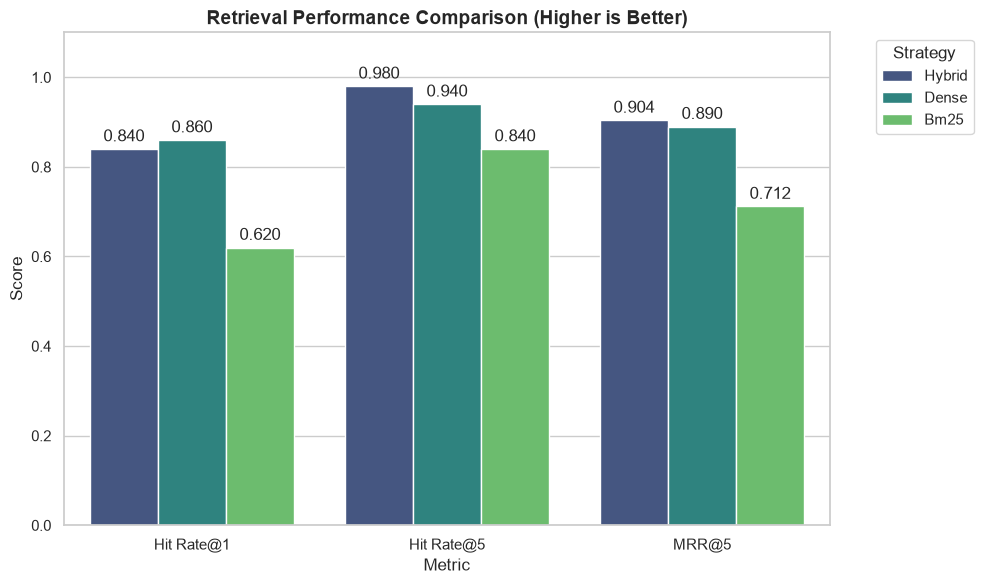

In [3]:
# Melt dataframe for easier plotting
df_melted = df.melt(id_vars=["Strategy", "Latency (ms)"], 
                    value_vars=["Hit Rate@1", "Hit Rate@5", "MRR@5"], 
                    var_name="Metric", 
                    value_name="Score")

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x="Metric", y="Score", hue="Strategy", palette="viridis")

plt.title("Retrieval Performance Comparison (Higher is Better)", fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.legend(title="Strategy", bbox_to_anchor=(1.05, 1), loc='upper left')

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig("../results/figures/retrieval_performance.png", dpi=300)
plt.show()

## 3. Visualize Latency Trade-off

C:\Users\sangw\AppData\Local\Temp\ipykernel_6792\2979277154.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="Strategy", y="Latency (ms)", palette="magma")


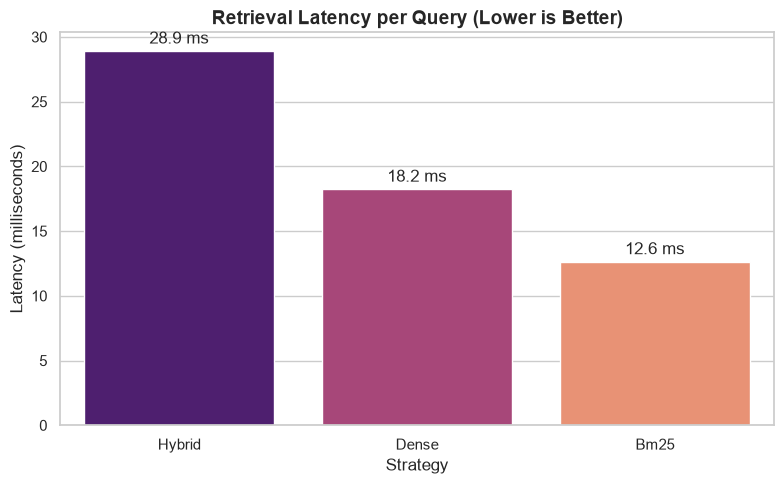

In [4]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df, x="Strategy", y="Latency (ms)", palette="magma")

plt.title("Retrieval Latency per Query (Lower is Better)", fontsize=14, fontweight='bold')
plt.ylabel("Latency (milliseconds)")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f ms', padding=3)
    
plt.tight_layout()
plt.savefig("../results/figures/latency_comparison.png", dpi=300)
plt.show()